In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

In [2]:
# make train/test/val split indices for R&D dataset bkg
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/rd/RD/merged.h5"
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    nevents = np.count_nonzero(mask)
indices = np.arange(nevents)
train_idx, test_idx = train_test_split(indices,train_size=0.5,random_state=76512)
test_idx, val_idx = train_test_split(test_idx,train_size=0.5,random_state=93014)
with h5py.File(base+"rd/RD/split_indices.h5","w") as fout:
    fout.create_dataset("train_inds",data=train_idx)
    fout.create_dataset("test_inds",data=test_idx)
    fout.create_dataset("val_inds",data=val_idx)

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"


fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]
    rd_sig = np.concatenate([frd[v][()][~mask].reshape(-1,1) for v in fitvars],axis=1)
    
frac_contam = 834/1000000 # contaminating with the same fraction as present in BB1 from LHCO
n_contam = int(rd_train.shape[0]*frac_contam/(1-frac_contam))
print(f"Target contam fraction : {frac_contam}")
print(f"Injecting {n_contam} signal on top of {rd_train.shape[0]} bkg")
print(f"Injected fraction : {n_contam/(n_contam+rd_train.shape[0])}")
rng = np.random.default_rng(seed=61844)
inject = rng.choice(rd_sig,size=n_contam,replace=False)
contam_rd_train = np.concatenate((rd_train,inject),axis=0)
rng.shuffle(contam_rd_train)

Target contam fraction : 0.000834
Injecting 417 signal on top of 500000 bkg
Injected fraction : 0.000833305023610309


# Train flows

In [3]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_BB1toContamPythRD_jets12",b1_train,b1_test,contam_rd_train,rd_test,fitvars,control=[],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

## jet1 rho

Training flow bkgFlow_step0_jet1_rho


Loss: 1.3299564337730407, p = 97: 100%|██████████| 609/609 [01:10<00:00,  8.59it/s] 


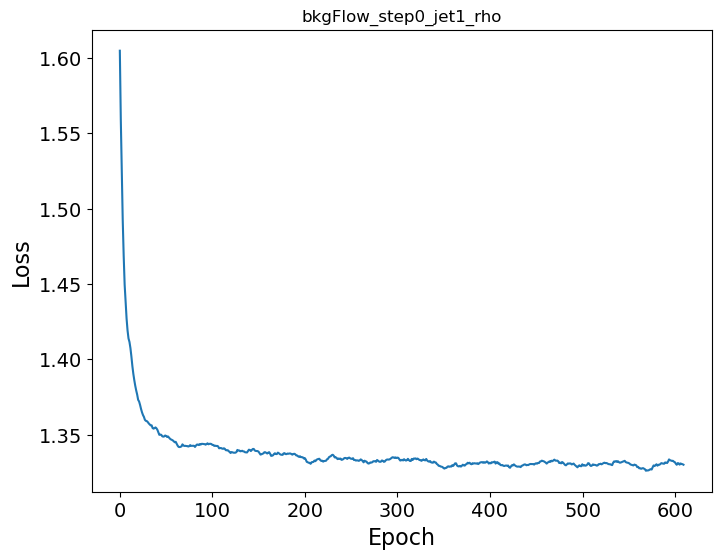

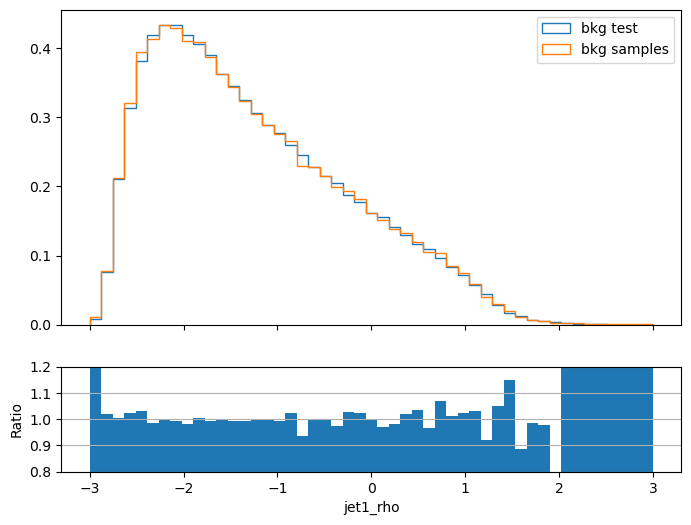

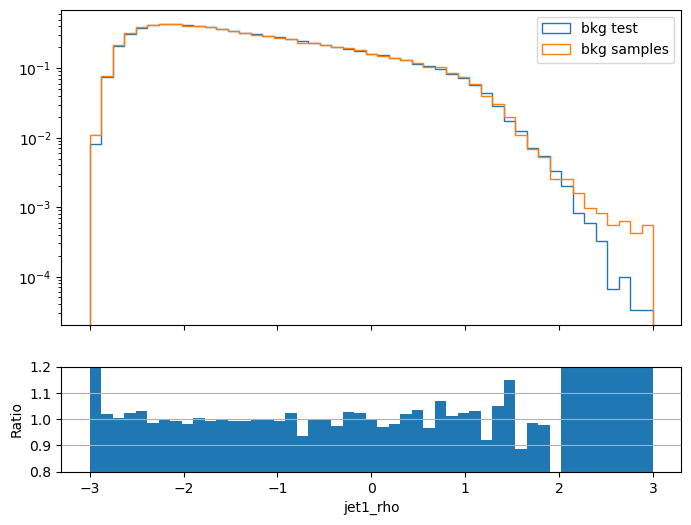

In [4]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 5
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_jet1_rho


Loss: 1.2772114396095275, p = 46: 100%|██████████| 250/250 [00:51<00:00,  4.90it/s]


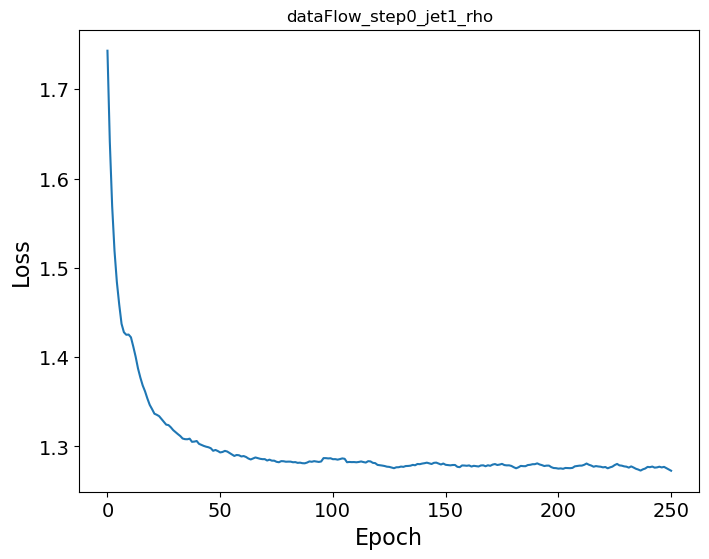

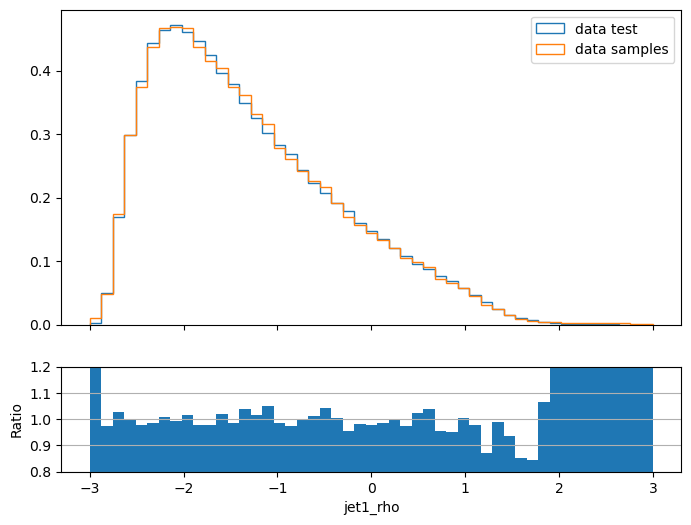

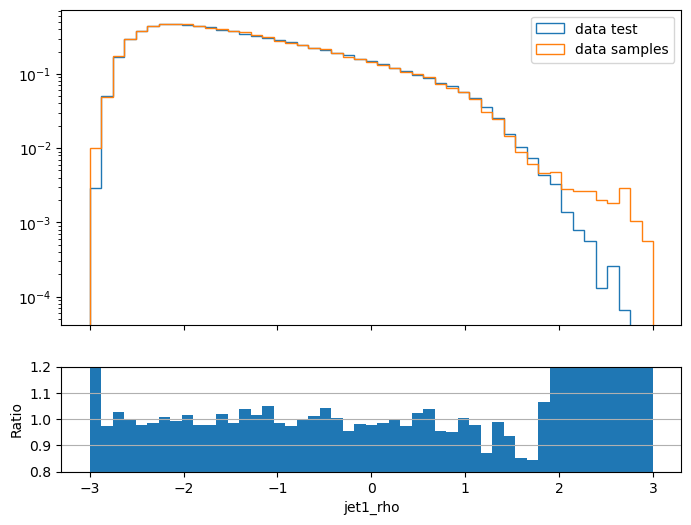

In [5]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 5
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:01<00:00, 14.86it/s]


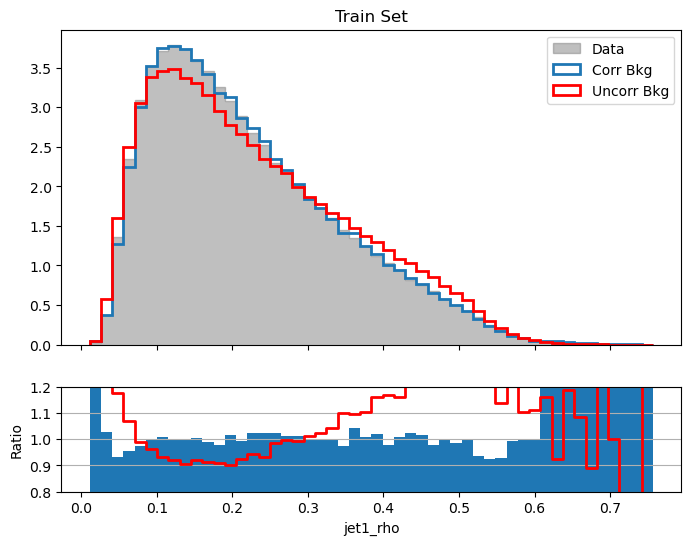

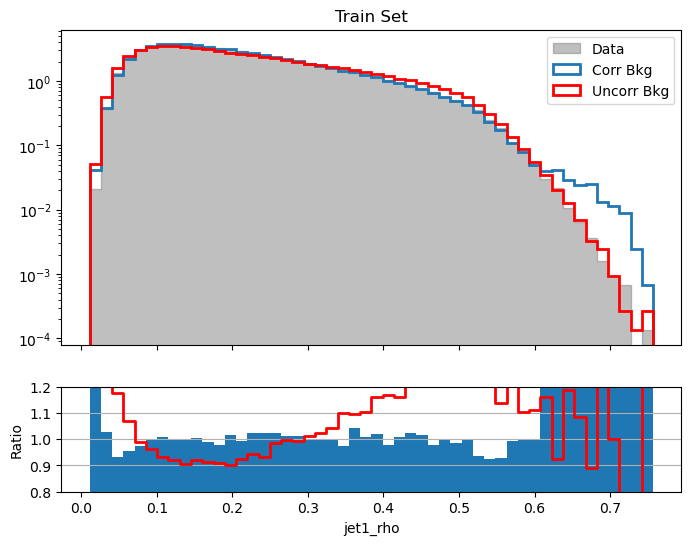

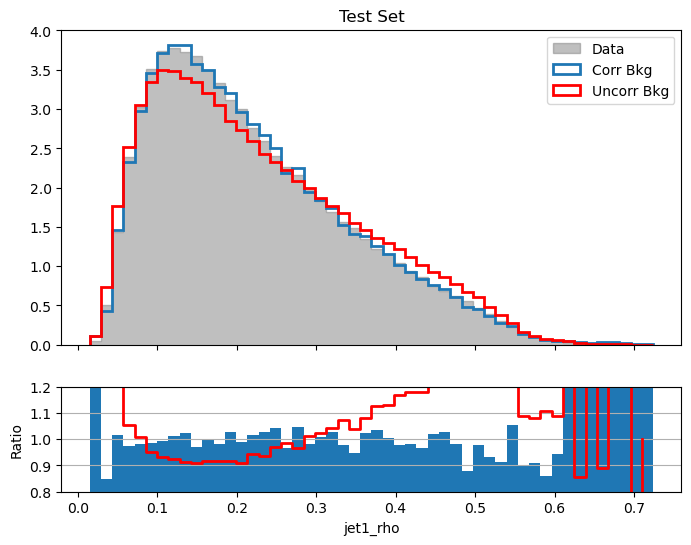

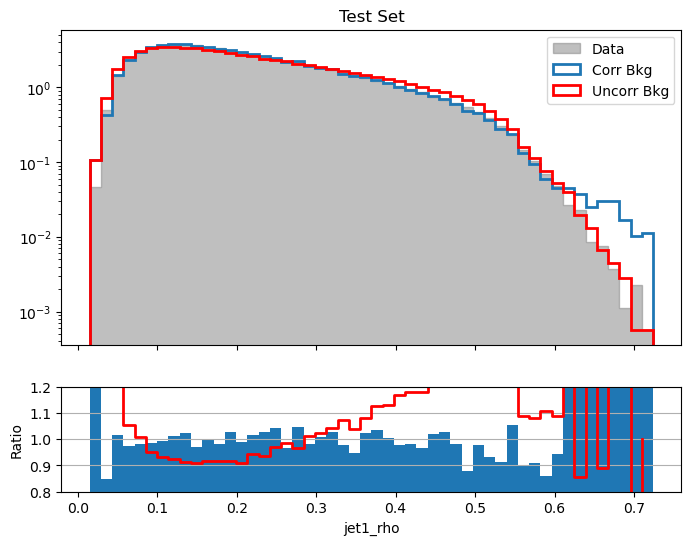

In [6]:
trainer.correctCurrent()
trainer.plotCurrent(50)

In [7]:
trainer.stepForward()

## jet1 tau21

Training flow bkgFlow_step1_jet1_tau21


Loss: 1.3680677998065949, p = 0: 100%|██████████| 249/249 [00:51<00:00,  4.79it/s] 


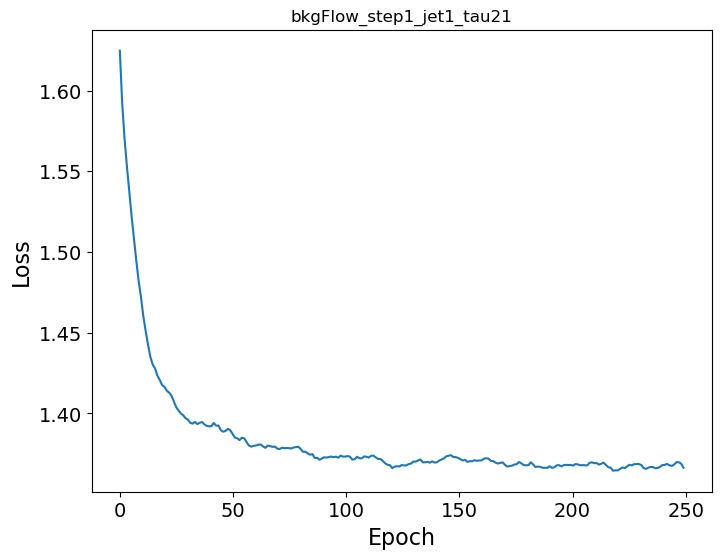

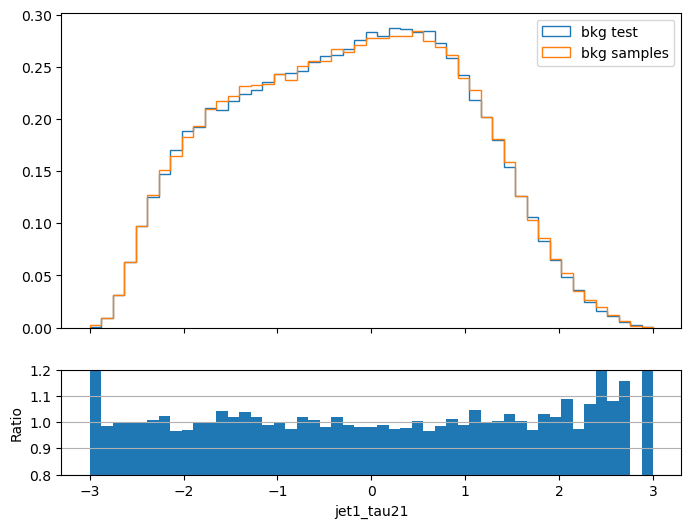

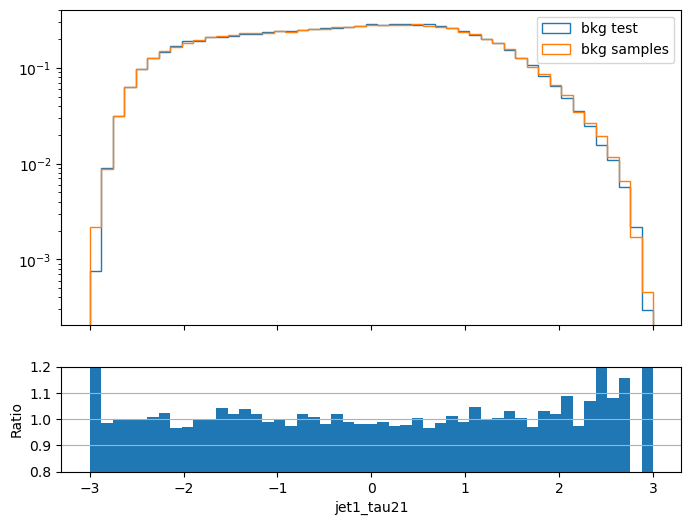

In [9]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 5
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_jet1_tau21


Loss: 1.3549313414096833, p = 194: 100%|██████████| 500/500 [01:42<00:00,  4.86it/s]


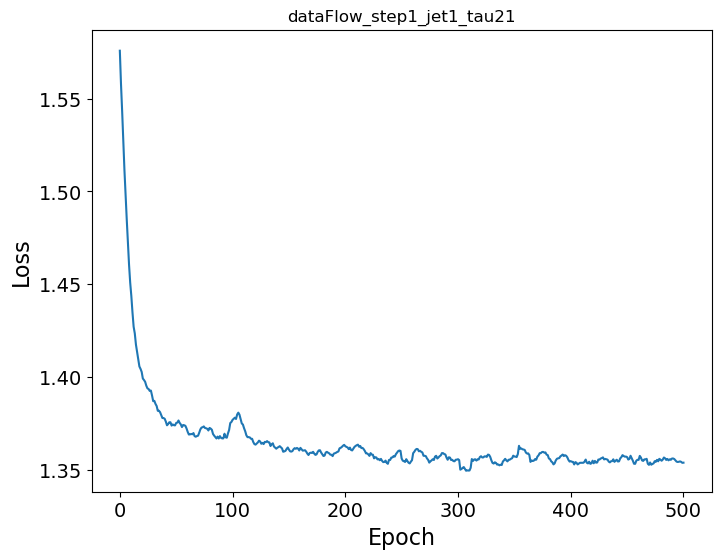

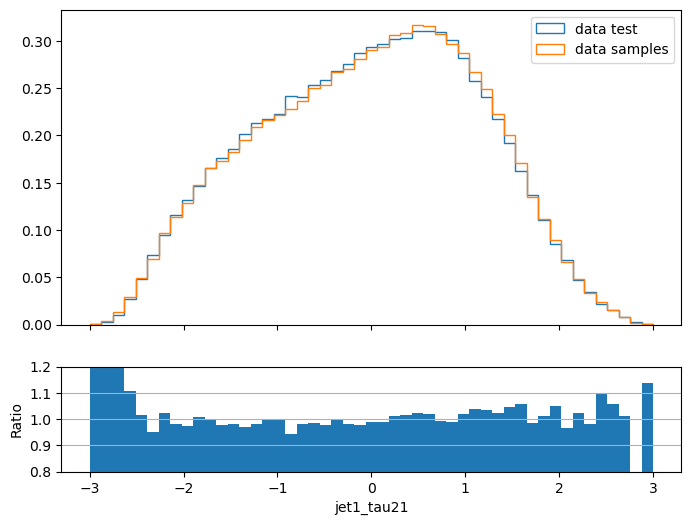

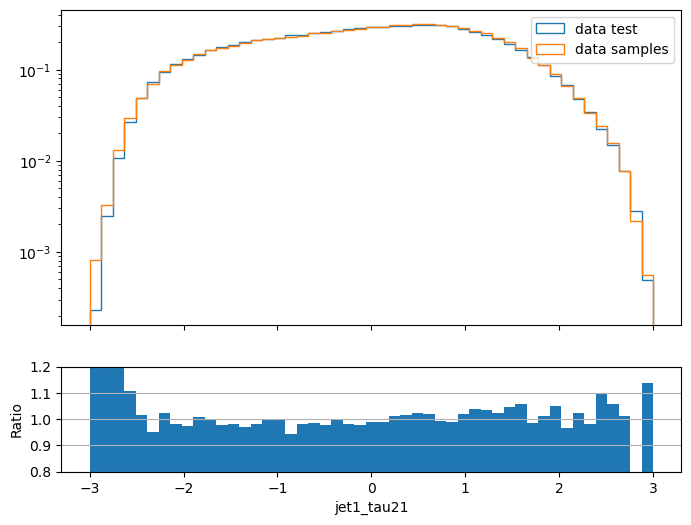

In [12]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:01<00:00, 15.00it/s]


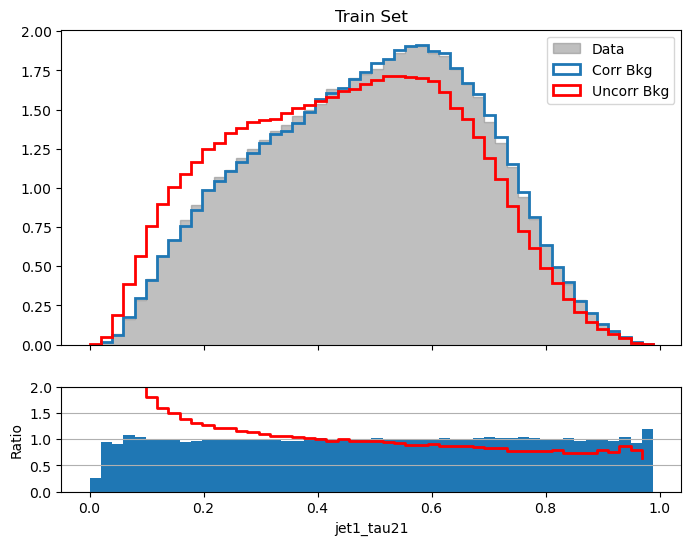

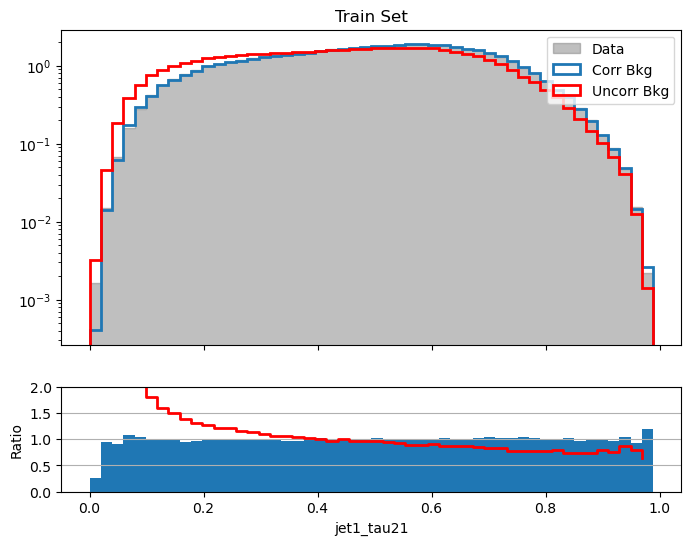

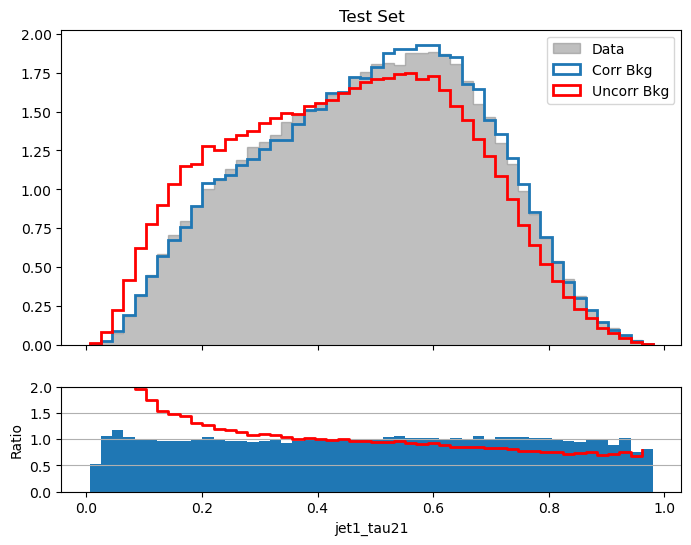

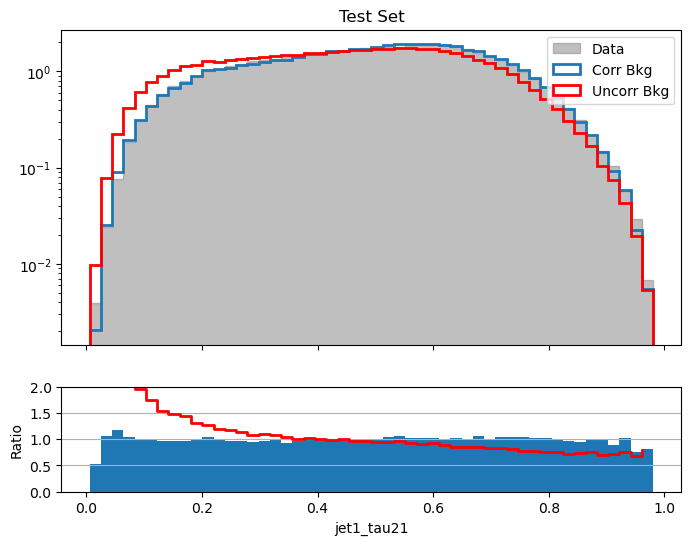

In [13]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [14]:
trainer.stepForward()

## jet1 tau32

Training flow bkgFlow_step2_jet1_tau32


Loss: 0.8947003102302551, p = 162: 100%|██████████| 749/749 [02:35<00:00,  4.81it/s]


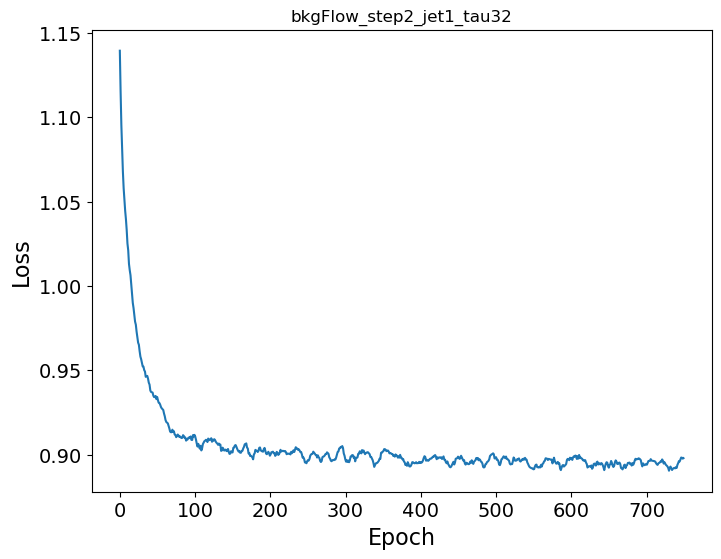

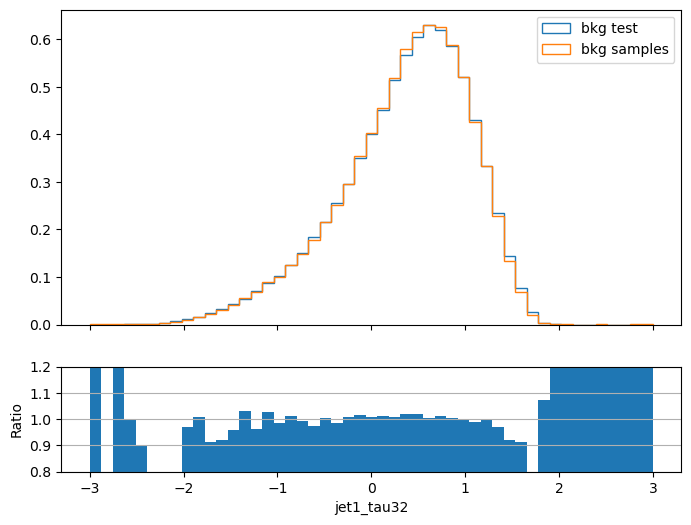

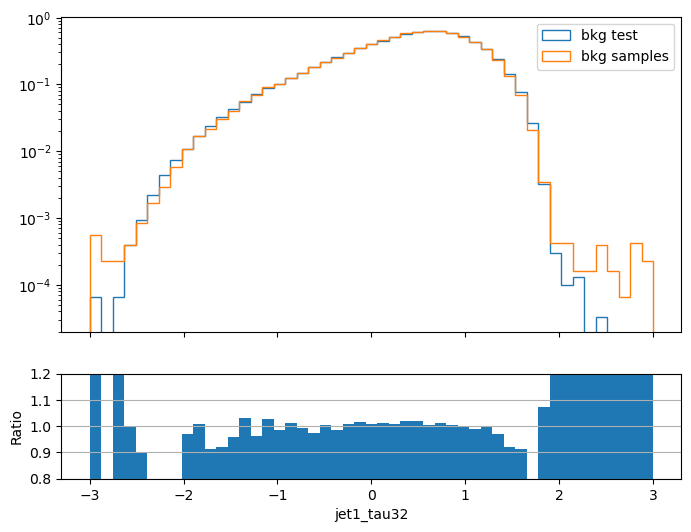

In [18]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step2_jet1_tau32


Loss: 0.8338627928495407, p = 87: 100%|██████████| 750/750 [02:36<00:00,  4.80it/s] 


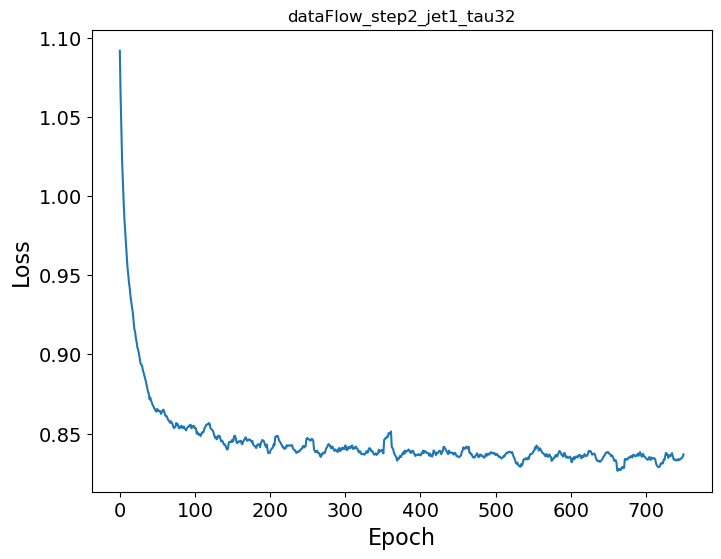

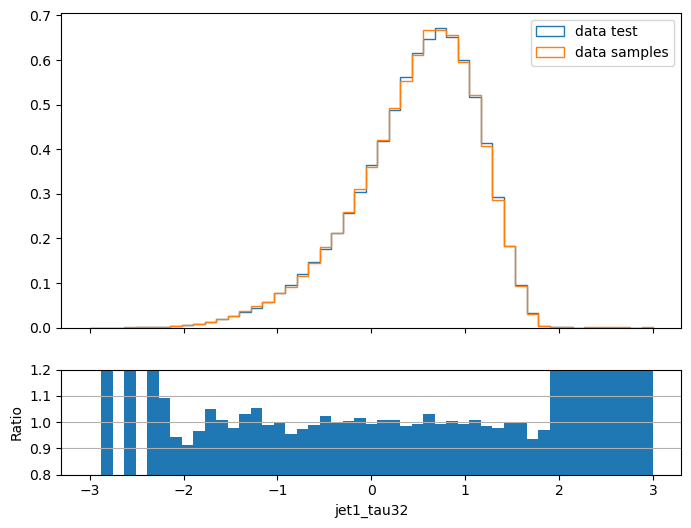

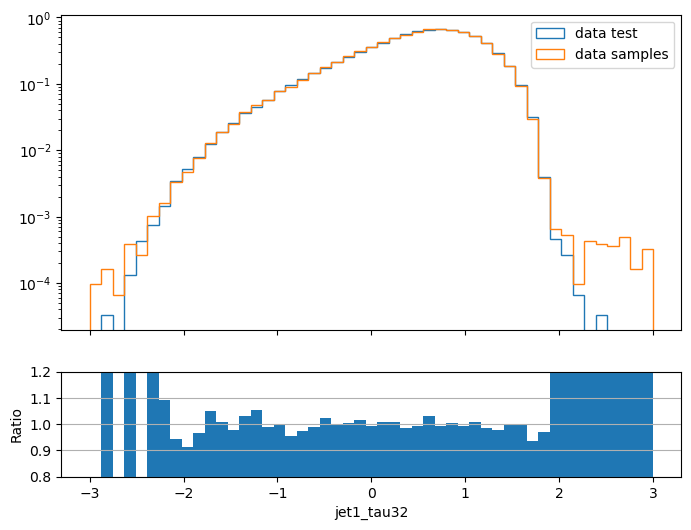

In [22]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:01<00:00, 12.50it/s]


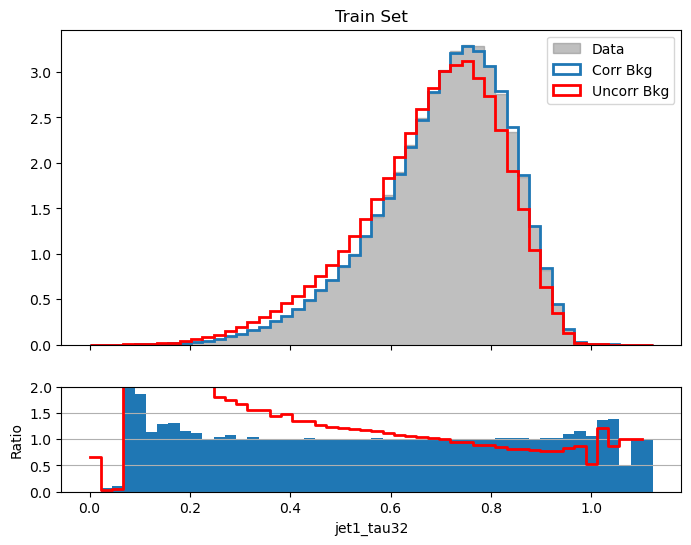

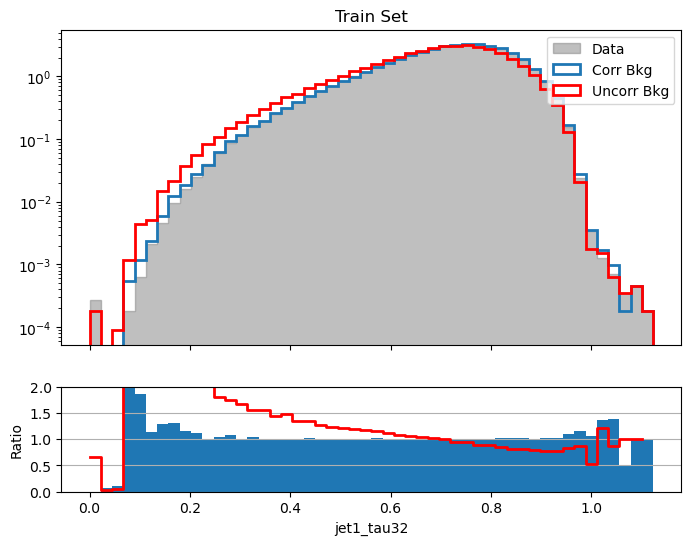

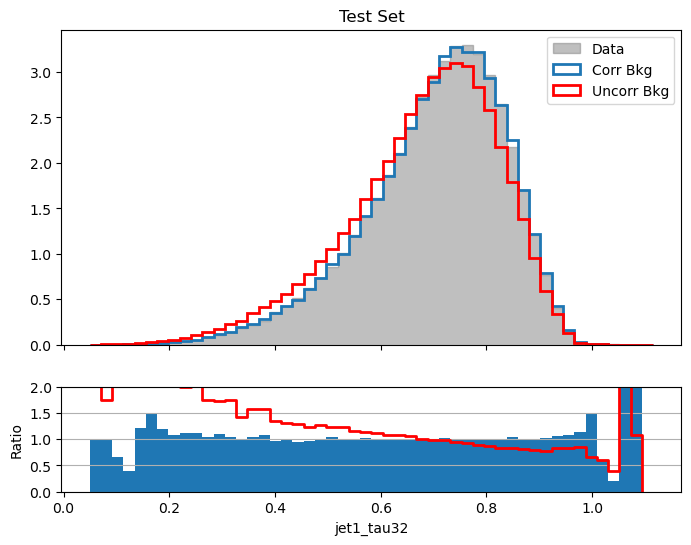

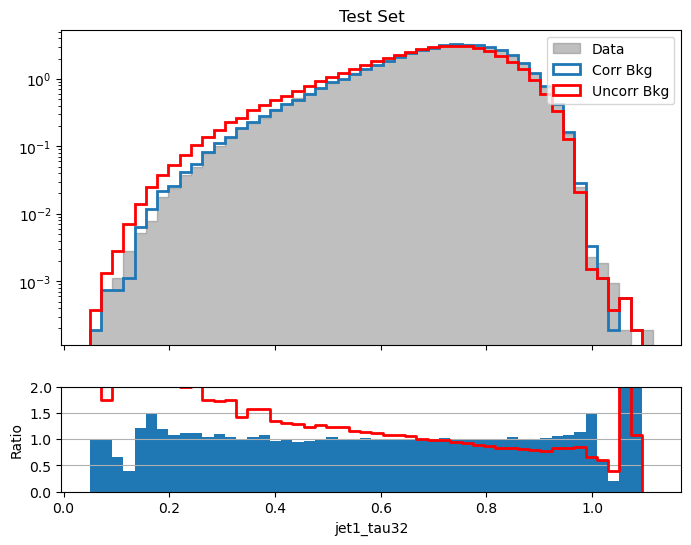

In [23]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [24]:
trainer.stepForward()

## jet1 tau43

Training flow bkgFlow_step3_jet1_tau43


Loss: 0.43502923935651777, p = 63: 100%|██████████| 749/749 [02:36<00:00,  4.77it/s] 


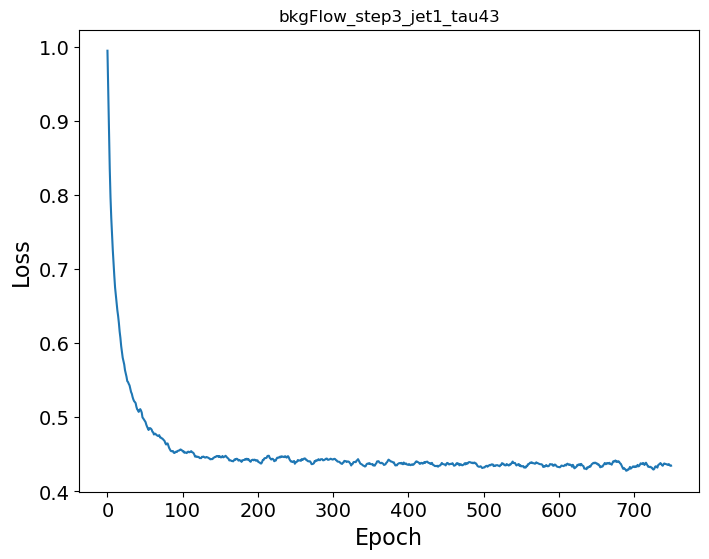

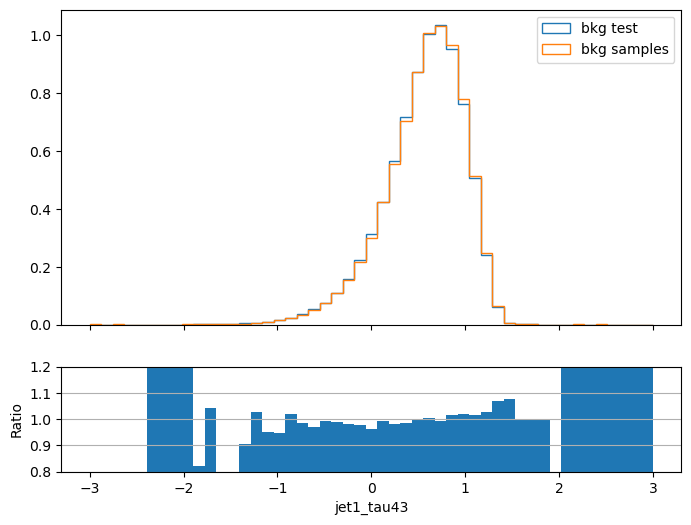

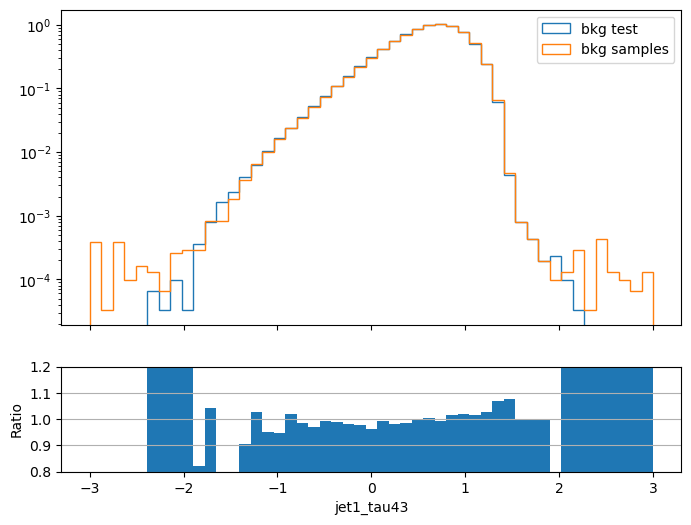

In [25]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step3_jet1_tau43


Loss: 0.36714090436697006, p = 87: 100%|██████████| 750/750 [02:34<00:00,  4.85it/s] 


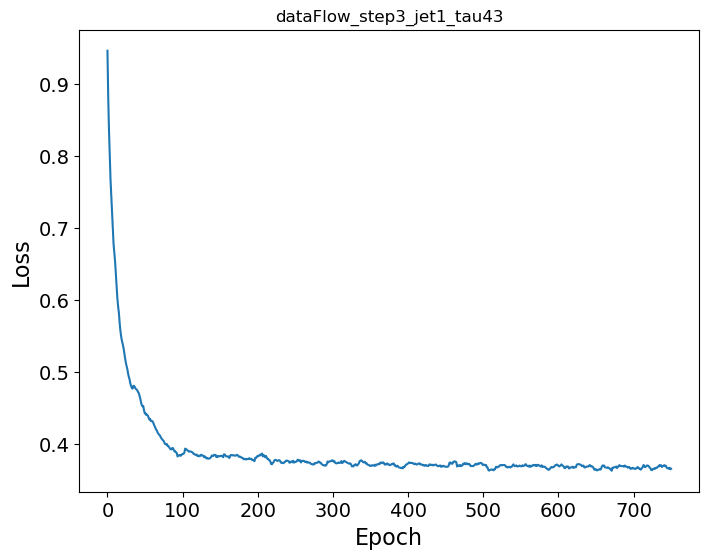

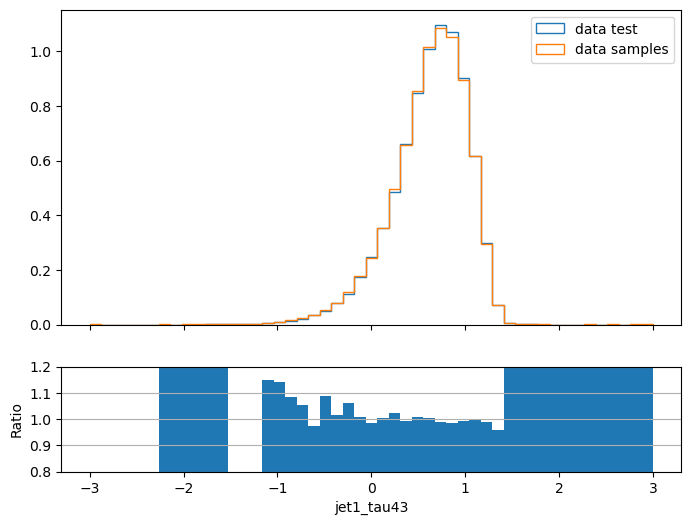

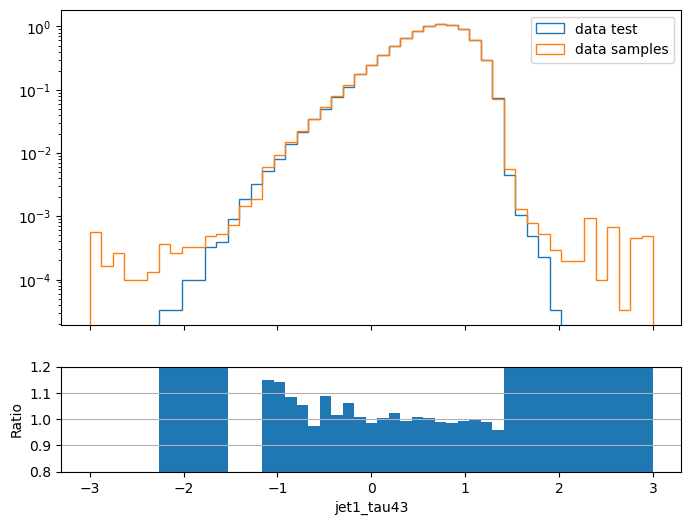

In [27]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.49it/s]


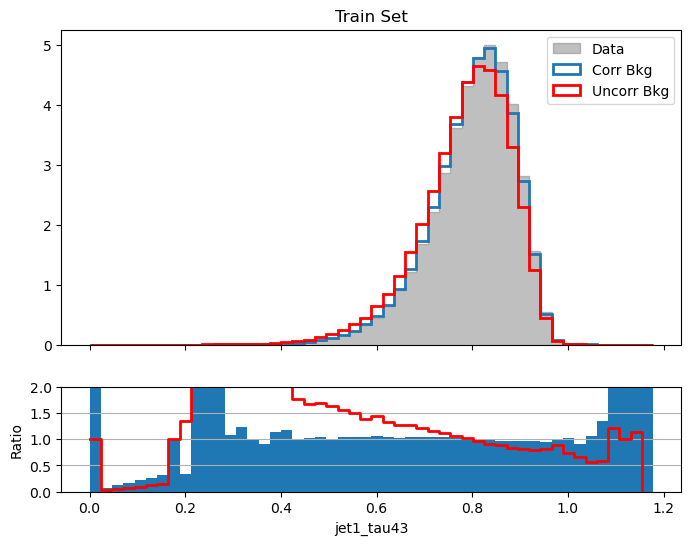

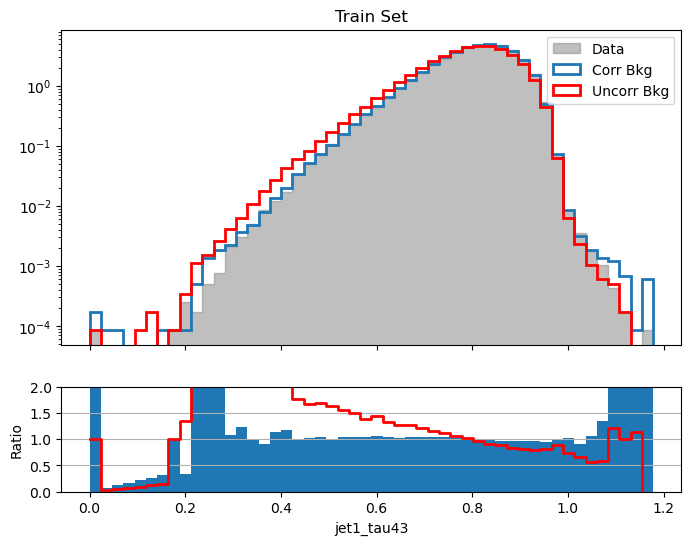

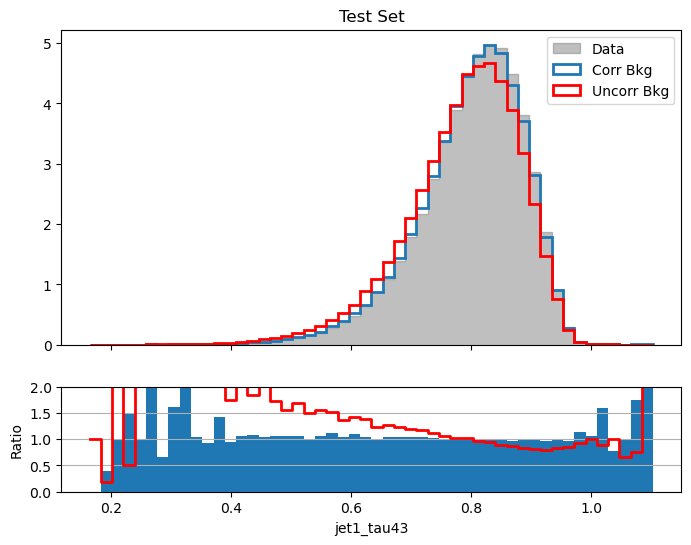

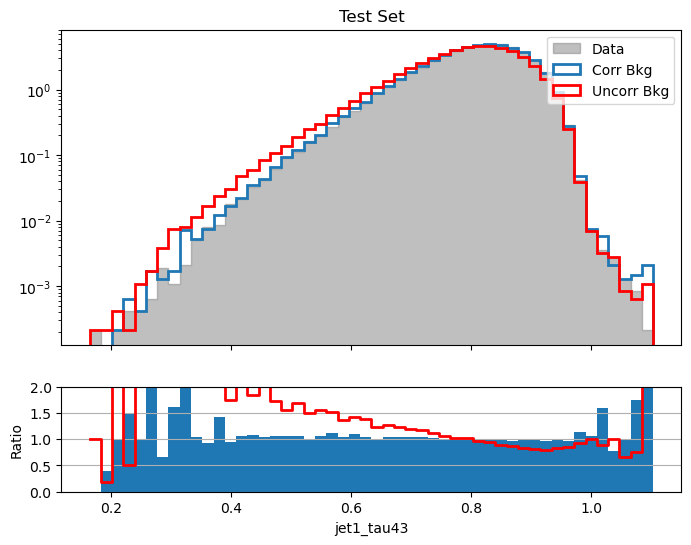

In [28]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [29]:
trainer.stepForward()

## jet2 rho

Training flow bkgFlow_step4_jet2_rho


Loss: 0.54351822078228, p = 107: 100%|██████████| 749/749 [02:37<00:00,  4.76it/s]  


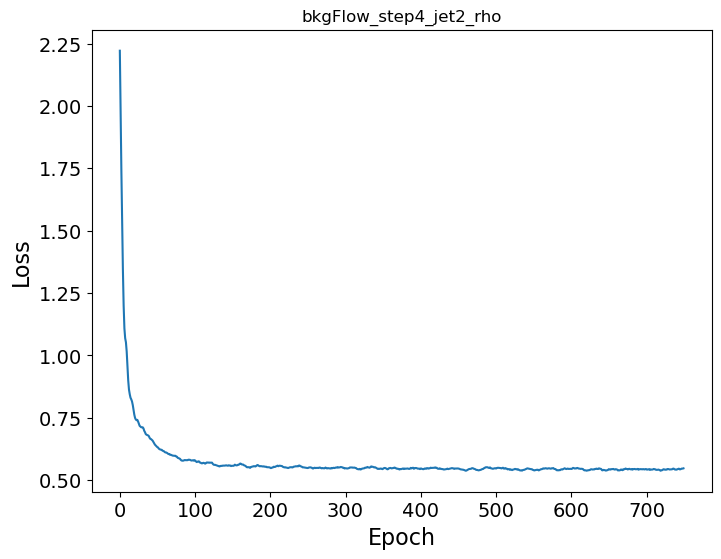

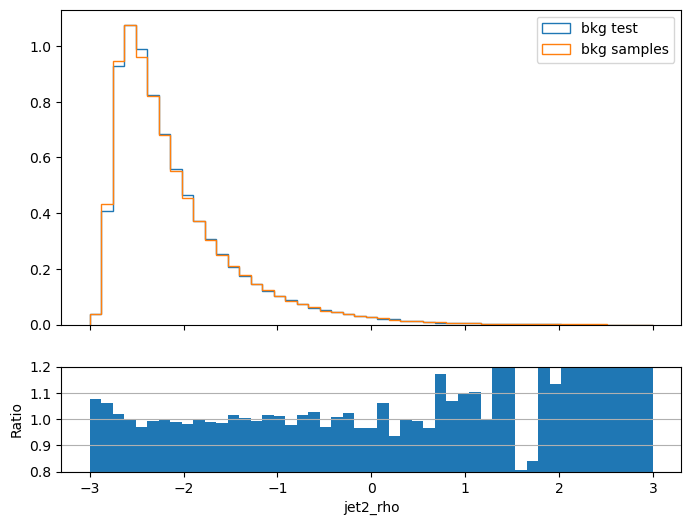

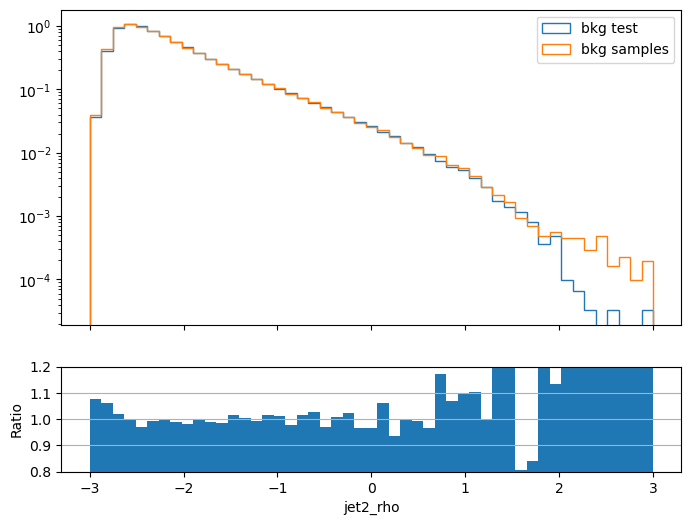

In [30]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step4_jet2_rho


Loss: 0.4766476392745972, p = 36: 100%|██████████| 750/750 [02:34<00:00,  4.85it/s]  


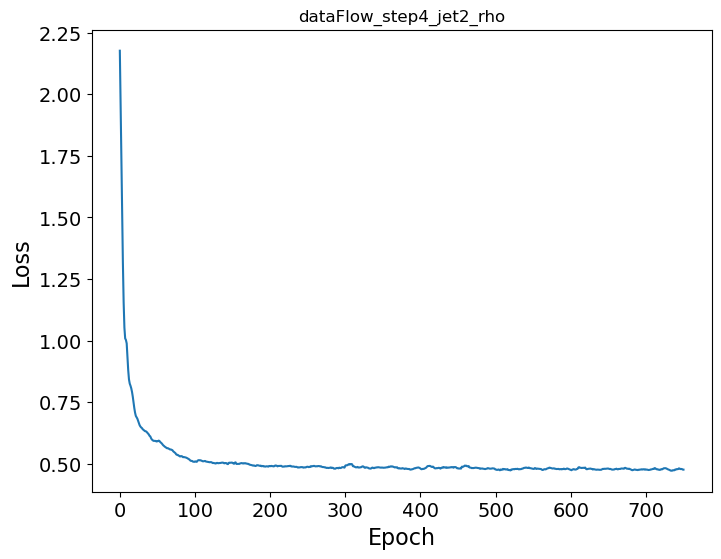

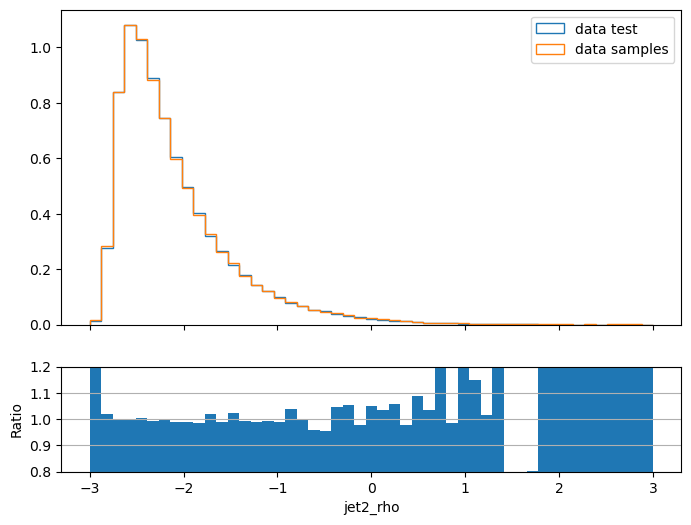

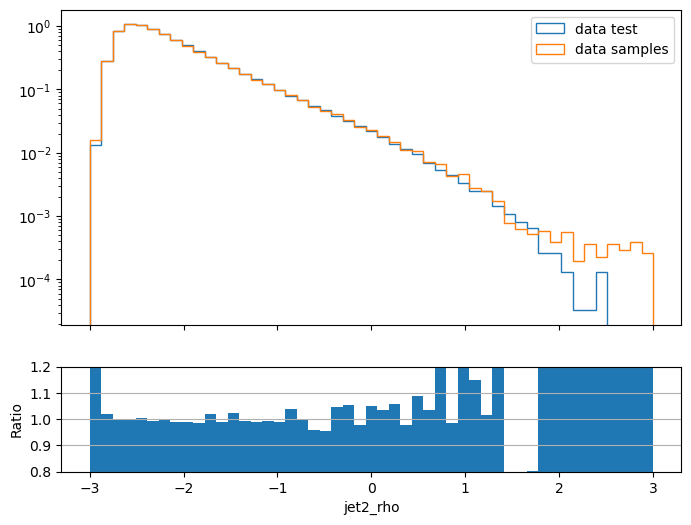

In [31]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.14it/s]


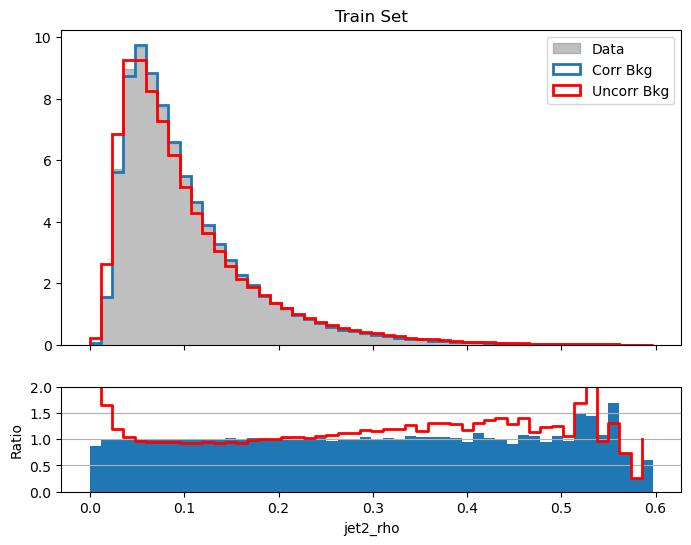

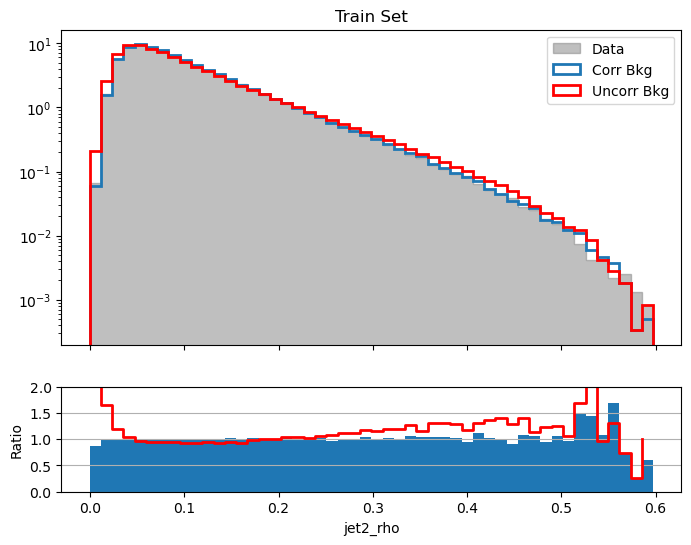

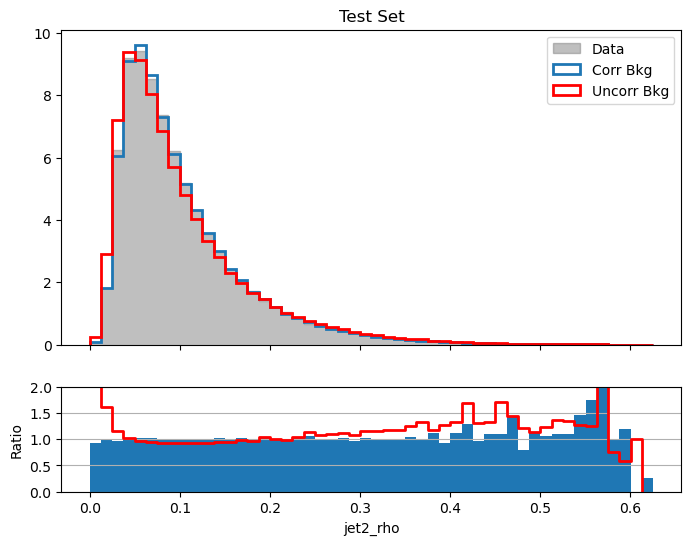

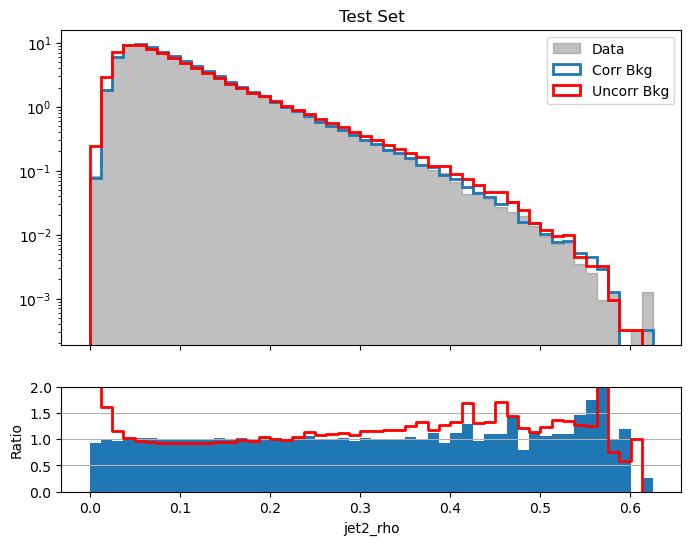

In [32]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [33]:
trainer.stepForward()

## jet2 tau21

Training flow bkgFlow_step5_jet2_tau21


Loss: 1.401990373134613, p = 268: 100%|██████████| 749/749 [02:37<00:00,  4.76it/s] 


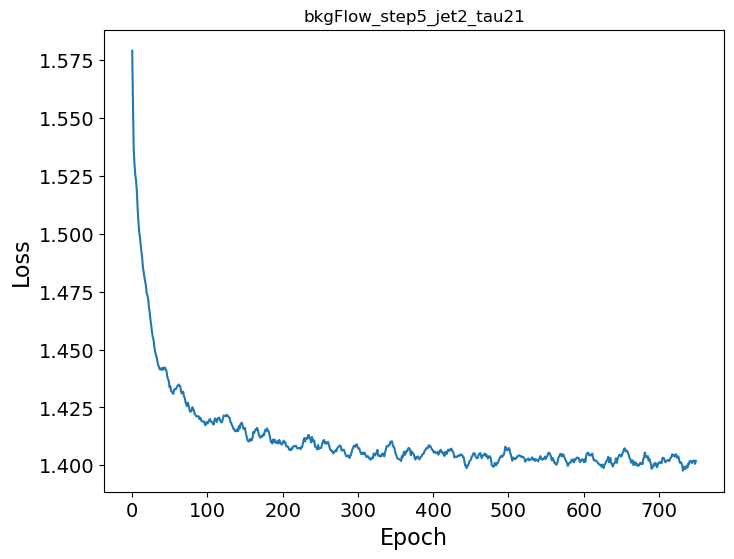

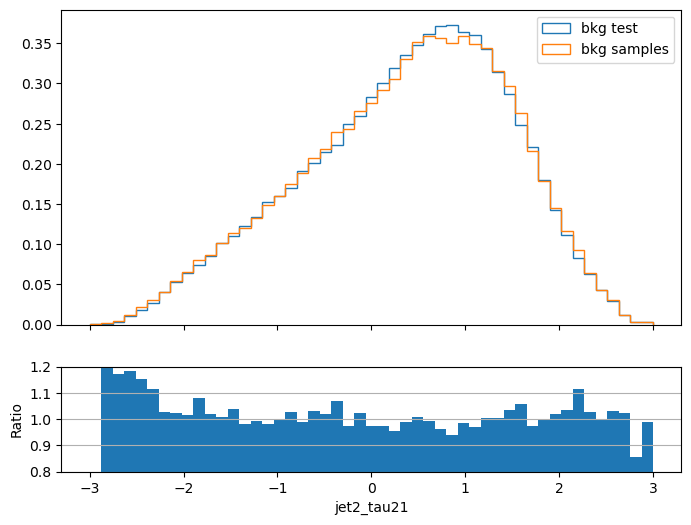

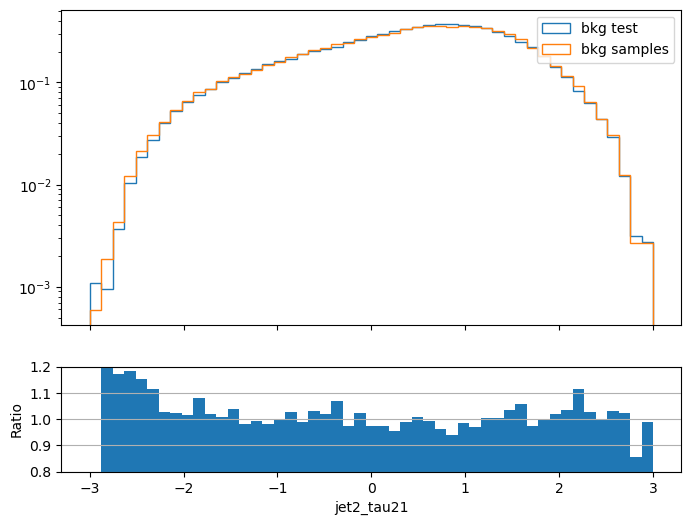

In [34]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step5_jet2_tau21


Loss: 1.367168265581131, p = 87: 100%|██████████| 750/750 [02:34<00:00,  4.86it/s]  


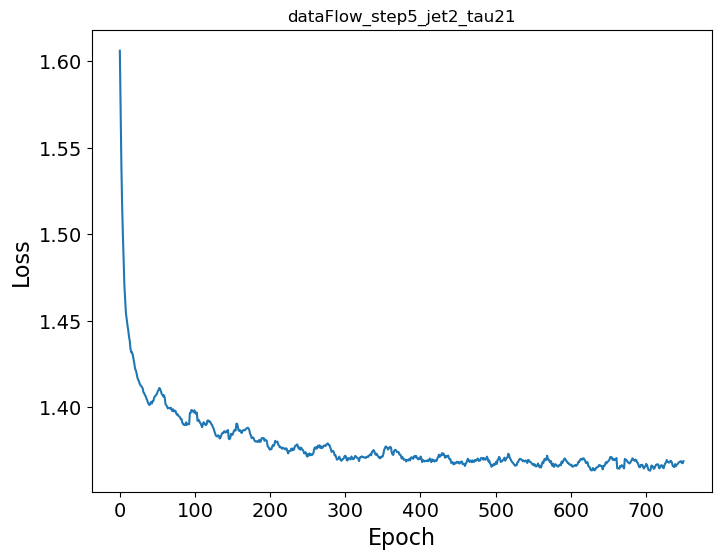

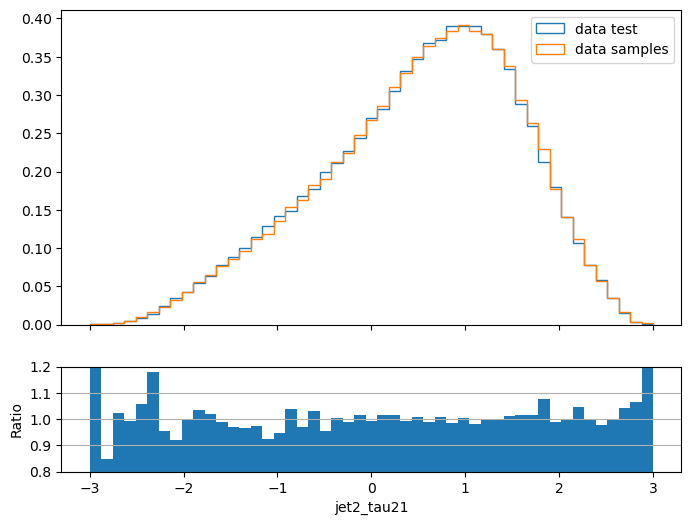

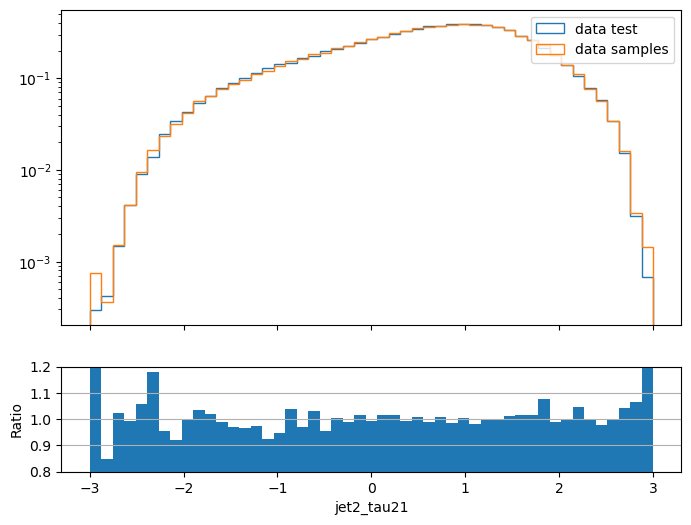

In [36]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.29it/s]


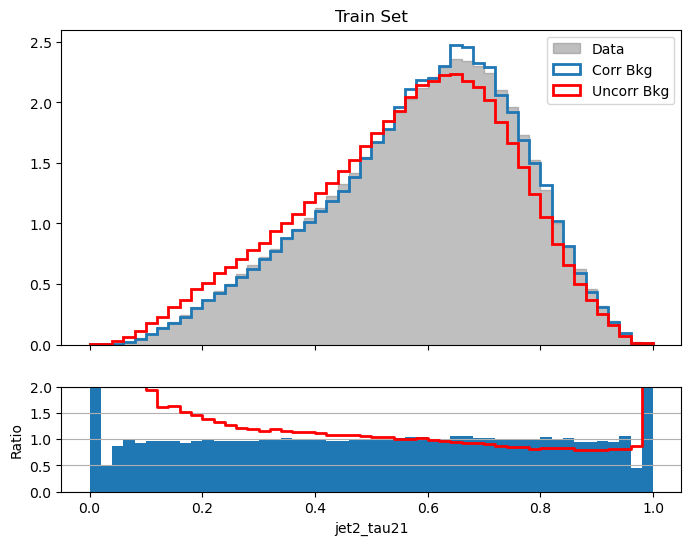

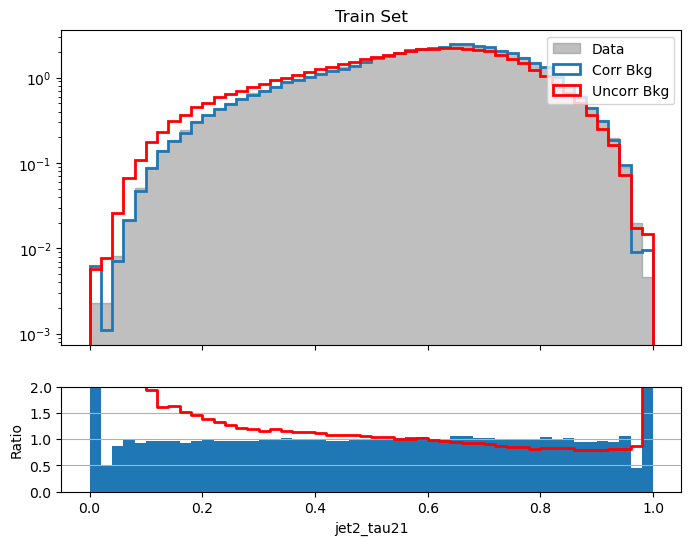

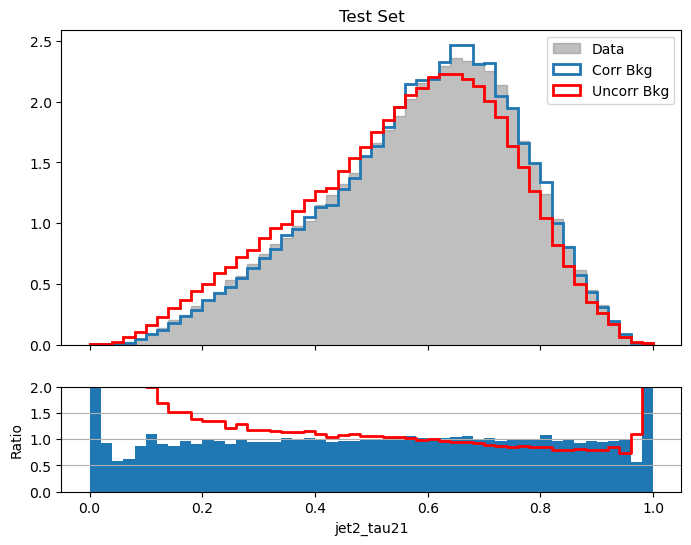

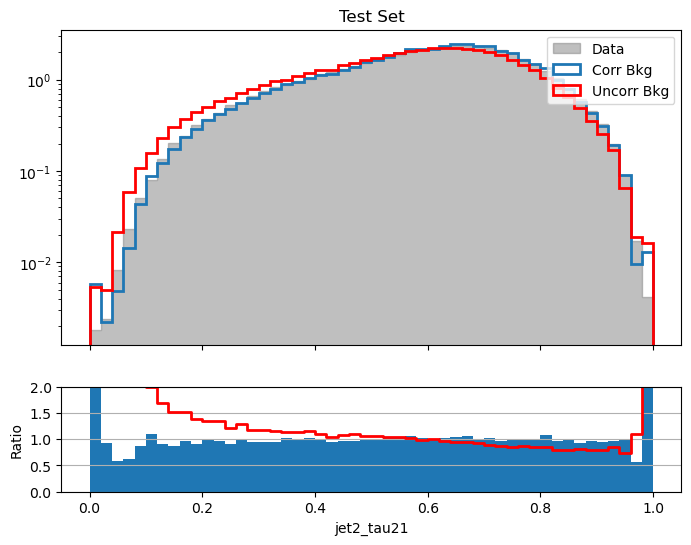

In [37]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [38]:
trainer.stepForward()

## jet2 tau32

Training flow bkgFlow_step6_jet2_tau32


Loss: 0.7857108563184738, p = 39: 100%|██████████| 749/749 [02:39<00:00,  4.70it/s] 


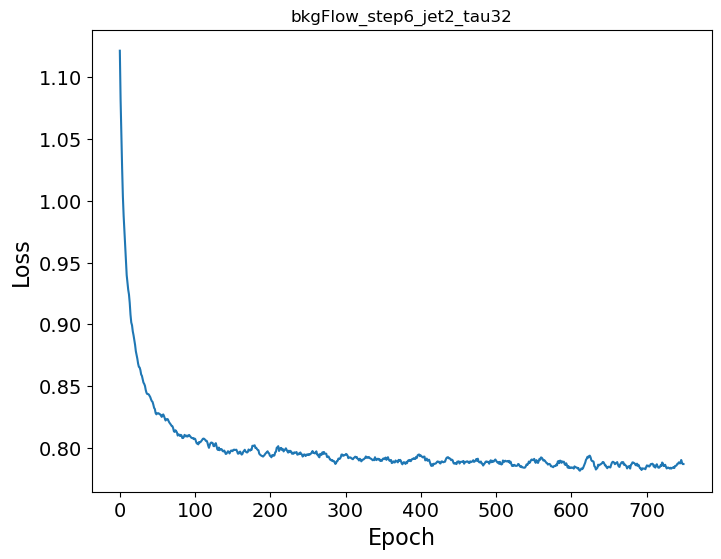

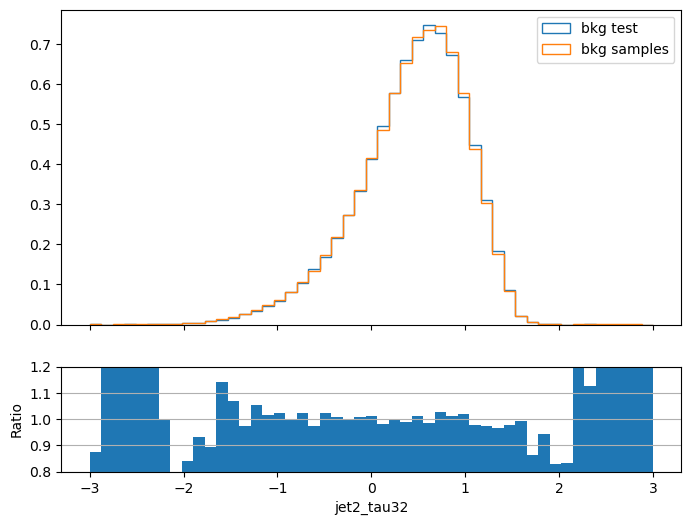

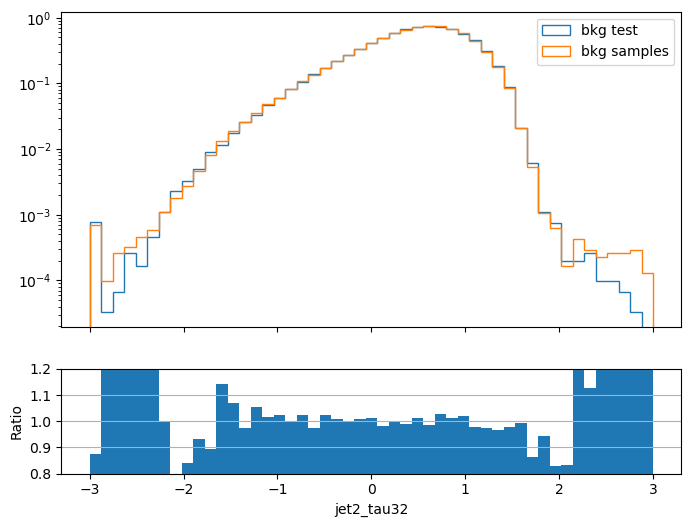

In [39]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step6_jet2_tau32


Loss: 0.7241887259483337, p = 87: 100%|██████████| 750/750 [02:36<00:00,  4.81it/s] 


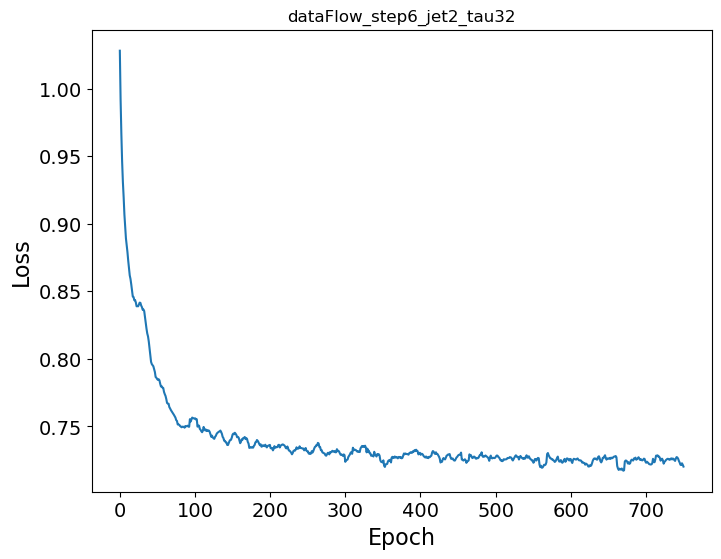

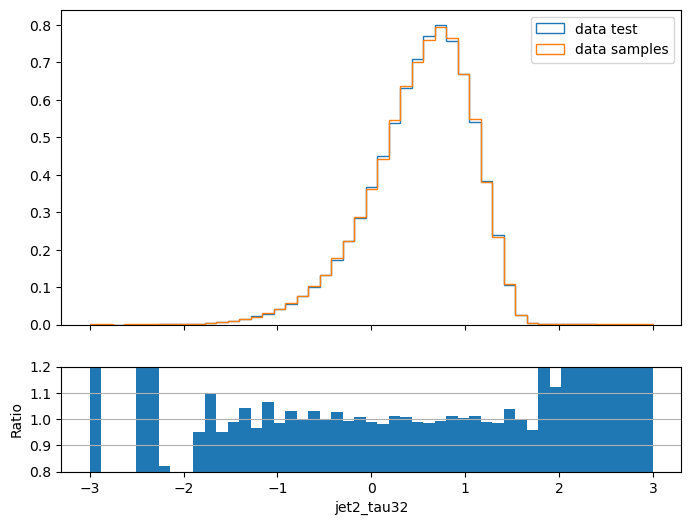

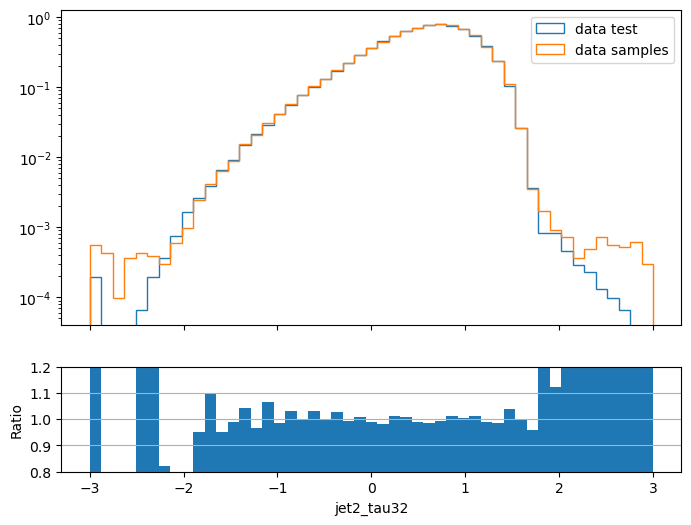

In [42]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 15
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.28it/s]


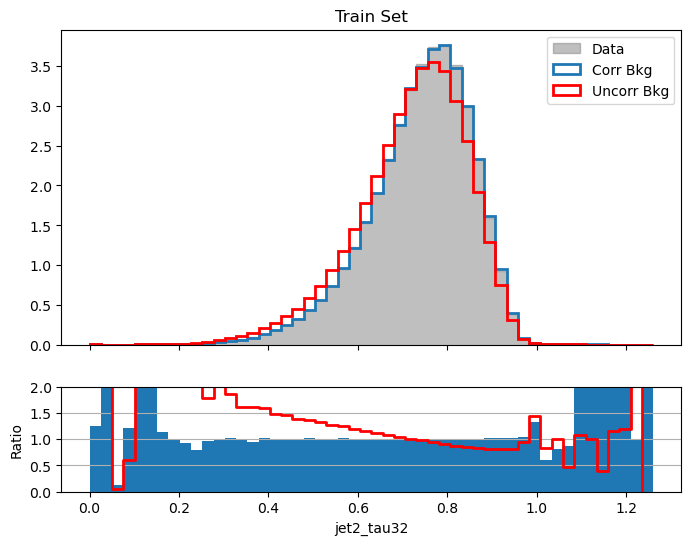

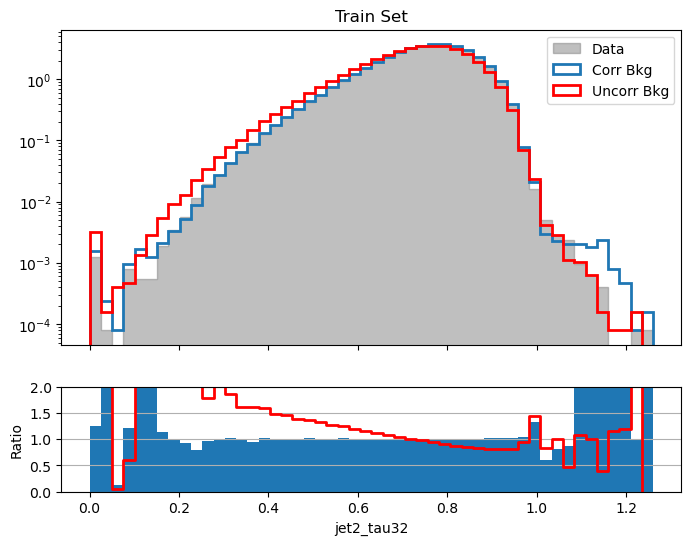

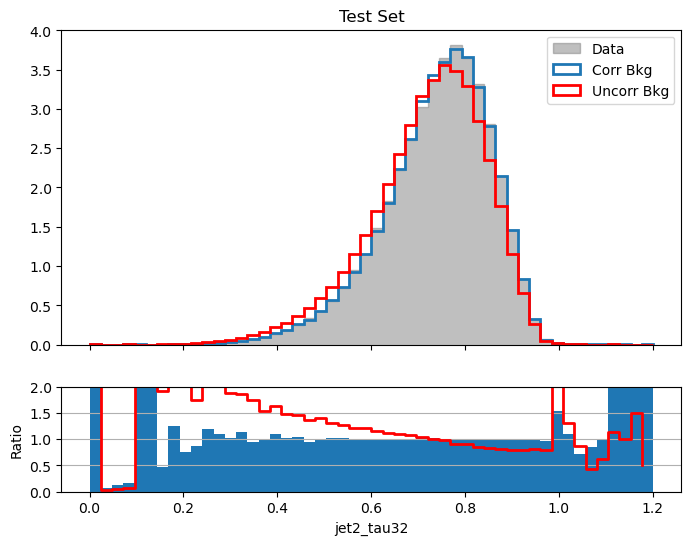

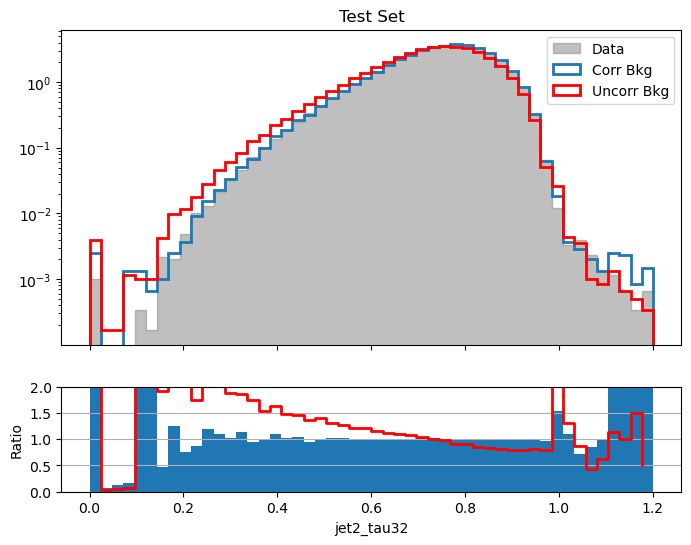

In [43]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [44]:
trainer.stepForward()

## jet2 tau43

Training flow bkgFlow_step7_jet2_tau43


Loss: 0.5052235454320908, p = 76: 100%|██████████| 999/999 [03:30<00:00,  4.74it/s] 


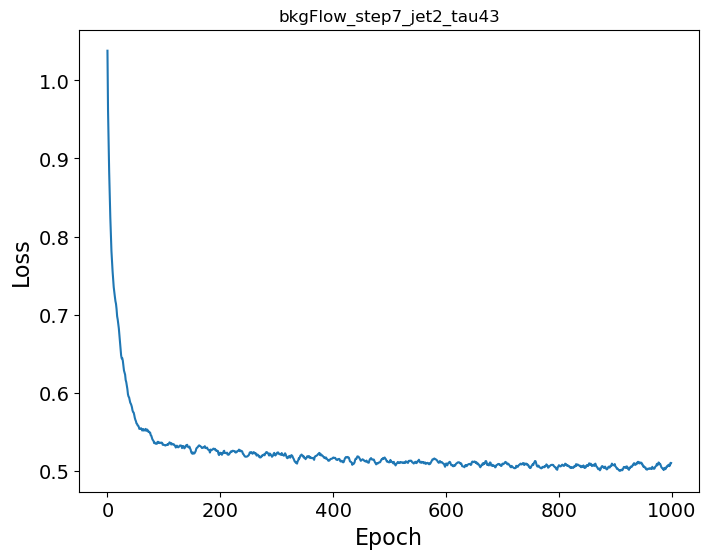

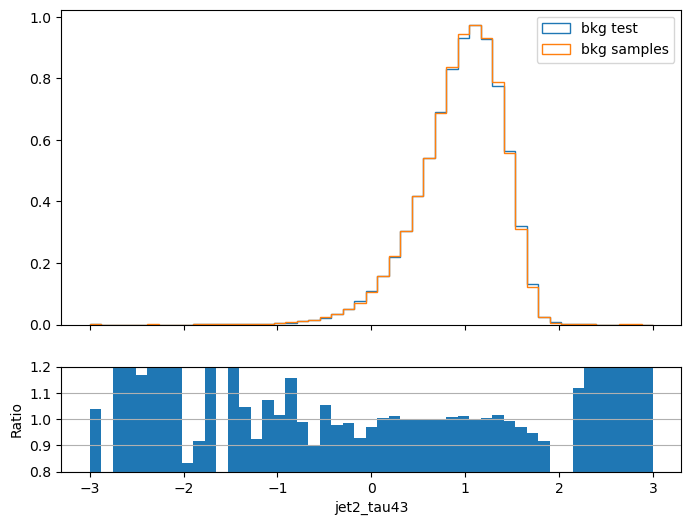

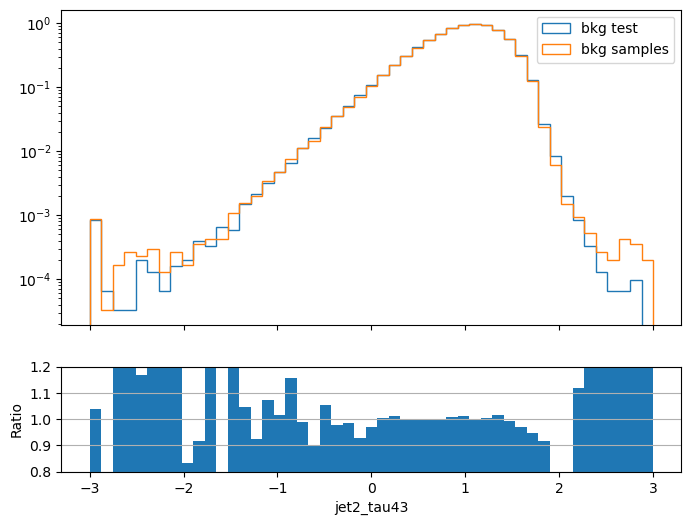

In [46]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step7_jet2_tau43


Loss: 0.43962441802024843, p = 82: 100%|██████████| 1000/1000 [03:28<00:00,  4.80it/s]


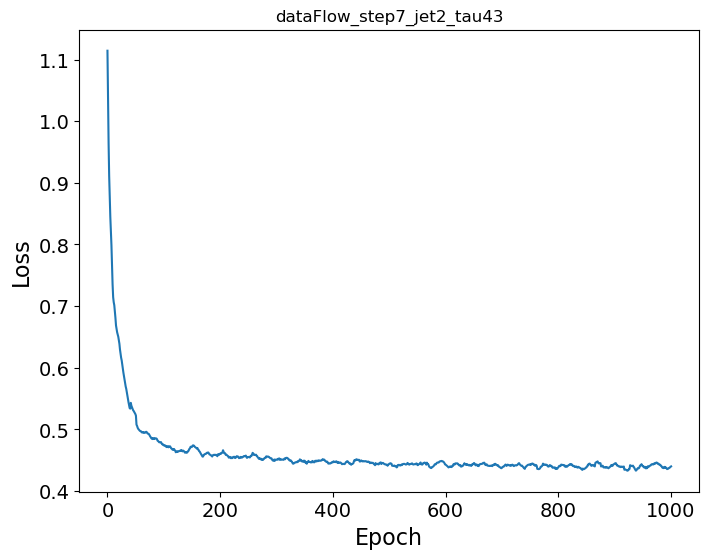

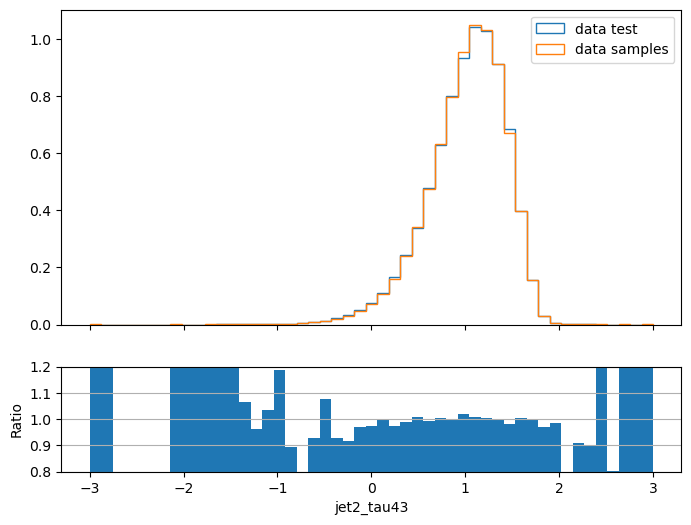

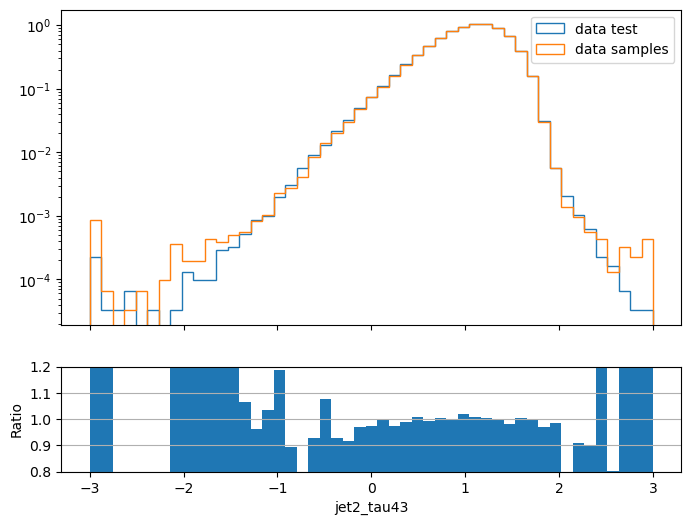

In [47]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.32it/s]


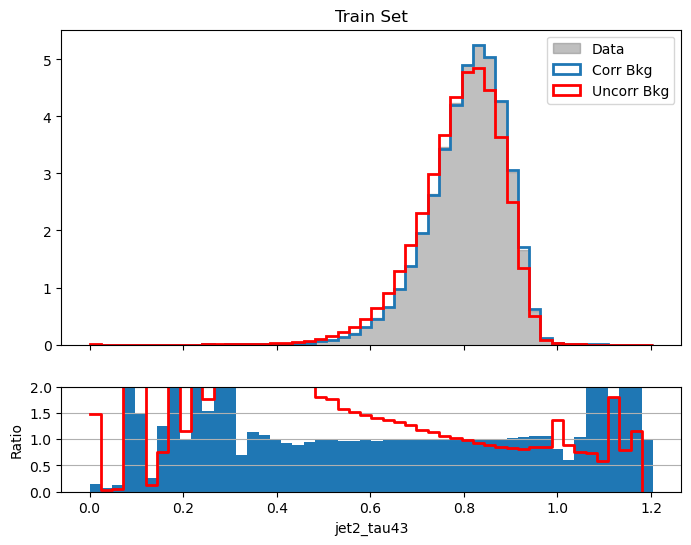

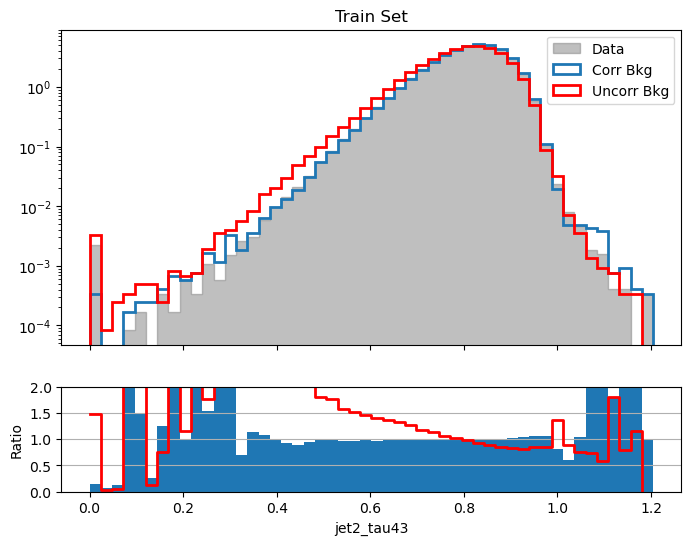

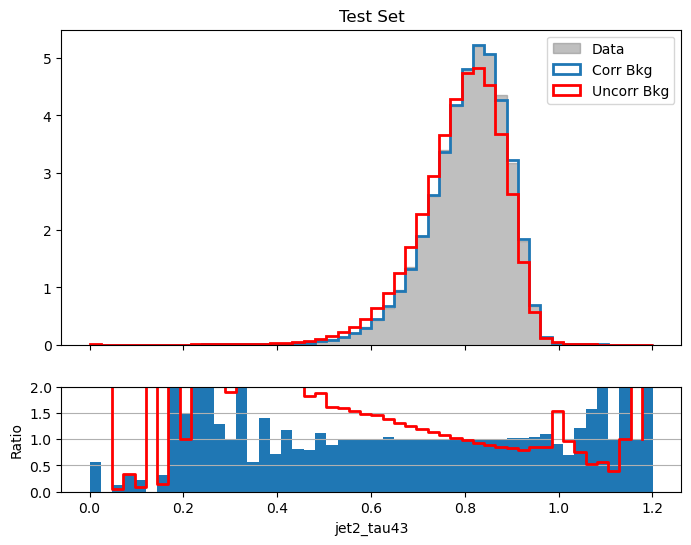

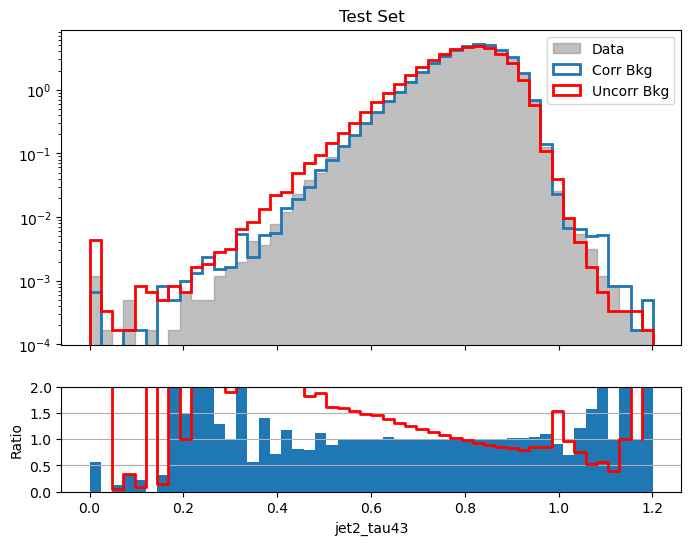

In [48]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])